In [48]:
from scapy.all import rdpcap, TCP, IP
import pandas as pd
import os


In [49]:
def analyze_pcap(pcap_file):
    packets = rdpcap(pcap_file)
    total_bytes_sent = 0
    total_bytes_received = 0
    external_requests = set()
    timestamps = []

    for pkt in packets:
        if IP in pkt and TCP in pkt:
            ip_layer = pkt[IP]
            tcp_layer = pkt[TCP]
            packet_size = len(pkt)

            timestamps.append(pkt.time)

            if tcp_layer.dport in [80, 443]:
                total_bytes_sent += packet_size
                external_requests.add(ip_layer.dst)
            elif tcp_layer.sport in [80, 443]:
                total_bytes_received += packet_size

    latency_ms = 0
    if timestamps:
        latency_ms = (max(timestamps) - min(timestamps)) * 1000

    return {
        "Bytes Sent (KB)": round(total_bytes_sent / 1024, 2),
        "Bytes Received (KB)": round(total_bytes_received / 1024, 2),
        "External Requests": len(external_requests),
        "Latency (ms)": round(latency_ms, 2)
    }


In [50]:
def analyze_multiple_agents(pcap_files):
    results = []
    for agent_name, filepath in pcap_files.items():
        stats = analyze_pcap(filepath)
        stats["Agent"] = agent_name
        results.append(stats)
    return pd.DataFrame(results)


In [54]:
# Replace these paths with your actual .pcap file locations
pcap_files = {#/Users/azza/Desktop/AI agents project/smolagents/examples/open_deep_research/output/Results/Norway
    "Qwen": "/Users/azza/Desktop/AI agents project/smolagents/examples/open_deep_research/output/Results/US-Iowa/Qwen_agent_traffic.pcap",
    "LLaMA 3": "/Users/azza/Desktop/AI agents project/smolagents/examples/open_deep_research/output/Results/US-Iowa/llama3_agent_traffic.pcap",
    "DeepSeek": "/Users/azza/Desktop/AI agents project/smolagents/examples/open_deep_research/output/Results/US-Iowa/deepseek_agent_traffic.pcap"
}

results_df = analyze_multiple_agents(pcap_files)
results_df


,Bytes Sent (KB),Bytes Received (KB),External Requests,Latency (ms),Agent
0,310.68,114.75,9,64890.43,Qwen
1,47.31,33.38,7,23211.09,LLaMA 3
2,538.85,2289.52,8,93942.28,DeepSeek


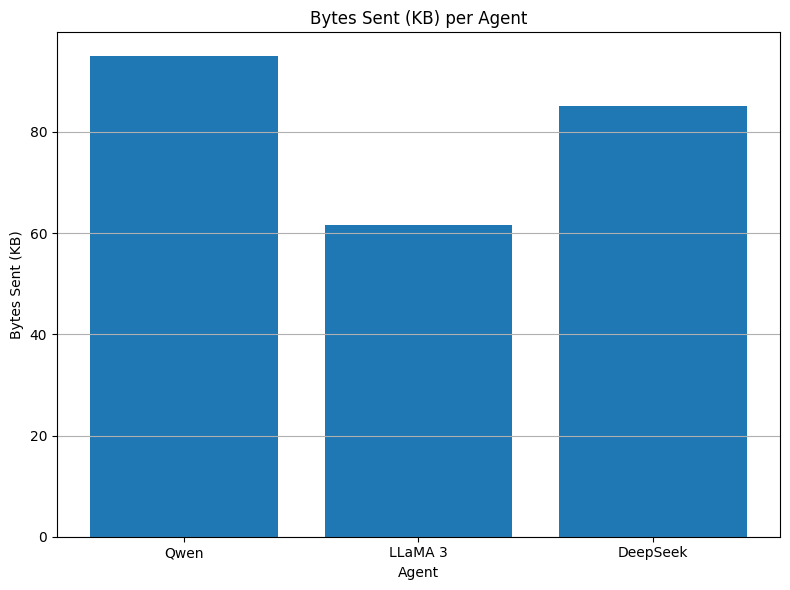

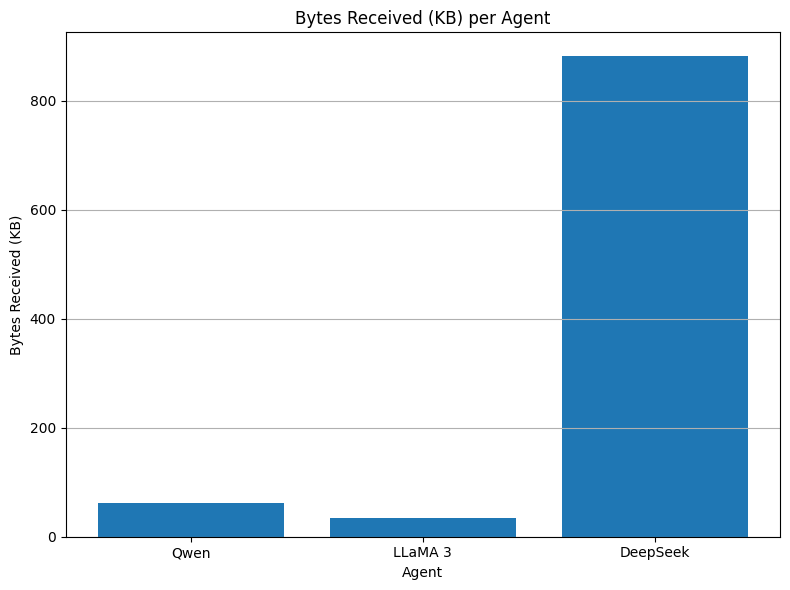

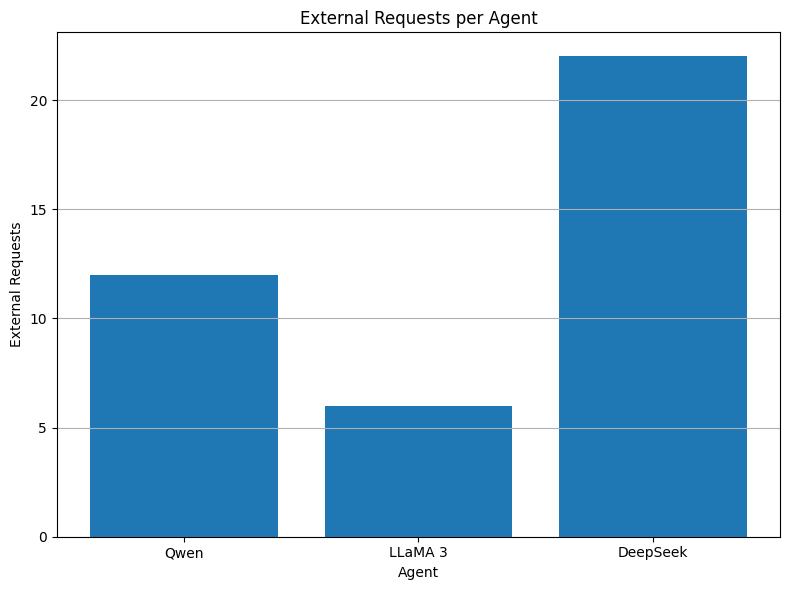

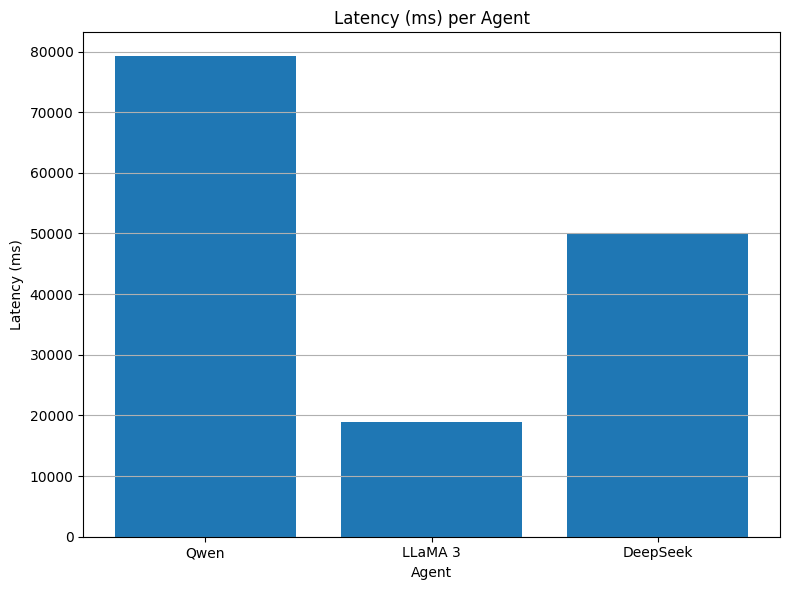

In [43]:
import matplotlib.pyplot as plt

metrics = ["Bytes Sent (KB)", "Bytes Received (KB)", "External Requests", "Latency (ms)"]

for metric in metrics:
    plt.figure(figsize=(8, 6))
    plt.bar(results_df["Agent"], results_df[metric])
    plt.title(metric + " per Agent")
    plt.ylabel(metric)
    plt.xlabel("Agent")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


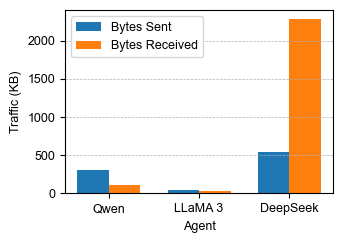

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Use sans-serif font for IEEE style
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "font.size": 9
})

# Data for plot
agents = results_df["Agent"]
sent = results_df["Bytes Sent (KB)"]
received = results_df["Bytes Received (KB)"]
x = np.arange(len(agents))
width = 0.35

# Figure size: 3.5 inches width (single-column), height auto-scaled
fig, ax = plt.subplots(figsize=(3.5, 2.5))

bars1 = ax.bar(x - width/2, sent, width, label='Bytes Sent')
bars2 = ax.bar(x + width/2, received, width, label='Bytes Received')

ax.set_ylabel("Traffic (KB)")
ax.set_xlabel("Agent")
ax.set_xticks(x)
ax.set_xticklabels(agents)
ax.legend()
ax.grid(True, axis='y', linestyle='--', linewidth=0.5)

# Tight layout and save as vector or high-resolution image
plt.tight_layout()
plt.savefig("US-Iowa_bytes_traffic.pdf", format="pdf", dpi=300)  # or .eps, or high-res PNG
plt.show()


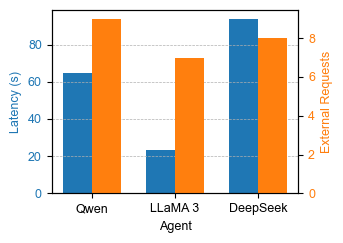

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Use IEEE-friendly font style
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "font.size": 9
})

agents = results_df["Agent"]
latency_sec = results_df["Latency (ms)"] / 1000  # Convert to seconds
requests = results_df["External Requests"]
x = np.arange(len(agents))
width = 0.35

# Create dual-axis figure
fig, ax1 = plt.subplots(figsize=(3.5, 2.5))

# Left y-axis: Latency in seconds
color1 = 'tab:blue'
bars1 = ax1.bar(x - width/2, latency_sec, width, label='Latency (s)', color=color1)
ax1.set_ylabel("Latency (s)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(x)
ax1.set_xticklabels(agents)
ax1.set_xlabel("Agent")
ax1.grid(True, axis='y', linestyle='--', linewidth=0.5)

# Right y-axis: External Requests
ax2 = ax1.twinx()
color2 = 'tab:orange'
bars2 = ax2.bar(x + width/2, requests, width, label='External Requests', color=color2)
ax2.set_ylabel("External Requests", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Export
fig.tight_layout()
plt.savefig("US-Iowa_latency_requests.pdf", format="pdf", dpi=300)
plt.show()
